In [1]:
import numpy as np
from scipy.integrate import solve_ivp as sp_solve_ivp
from scipy.integrate import odeint
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from typing import List
device = 'cpu'
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from sklearn.preprocessing import MinMaxScaler
from ftnode.utils import set_global_seed
from ftnode.node import (
    FTNODE, FeluSigmoidMLP,GeluSigmoidMLPfeaturized)

from scipy.optimize import root_scalar
import torchode

seed = 1234
set_global_seed(seed)

random_state = 67

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
def hysteresis_ode(t,x,lam):
    return lam+x-x**3

n_lam = 51
n_traj = 51
lams = np.linspace(-1,1,n_lam)
xs = np.linspace(-2,2,n_traj)


t_max = 0.25
n_colloc = 101


Xs = []
Us = []
t = np.linspace(0,t_max,n_colloc)
for lami in tqdm(lams):
    for x0 in xs:
        sol = sp_solve_ivp(
            hysteresis_ode,
            t_span = [0,t_max],
            y0 = np.array(x0).reshape(-1),
            t_eval = np.linspace(0,t_max,n_colloc),
            args = (lami,)
        )

        Xs.append(sol.y.T)
        Us.append([lami])
Xs = np.array(Xs)
Us = np.array(Us)

scaler = MinMaxScaler(feature_range=(-1,1))
scaler.fit(Xs.reshape(-1,1).reshape(-1,1))

  0%|          | 0/51 [00:00<?, ?it/s]

,feature_range,"(-1, ...)"
,copy,True
,clip,False


In [3]:
model_path = "../best_model-20-20-20.pth"

f = FeluSigmoidMLP(
    dims=[1,20,20,20, 1],
    activation=nn.SiLU(),
    lower_bound=-5,
    upper_bound=-0.1,
    init_type=None
)


g = GeluSigmoidMLPfeaturized(
    dims=[6, 20,20,20, 1],
    activation=nn.SiLU(),
    lower_bound=-2,
    upper_bound=2,
    freq_sample_step=1,
    feat_lower_bound=-1.5,
    feat_upper_bound=1.5,
    init_type=None
)

model = FTNODE(f, g).to(device)
model.load_state_dict(torch.load(model_path))
model.eval() #

f = model.f
g = model.g

f.eval()
g.eval()

GeluSigmoidMLPfeaturized(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=1, bias=True)
    )
  )
)

In [6]:
lam_lin = np.linspace(-1,1,501)
x_lin = np.linspace(-2,2,501)
x_lin_scaled = scaler.transform(x_lin.reshape(-1,1)).reshape(-1)

In [4]:
def process_solutions(solutions):
    x1 = []   # lower branch (before bifurcation)
    x2 = []   # middle branch (during bifurcation)
    x3 = []   # upper branch (after bifurcation)

    bifur = False
    bifur_indices = []

    for idx, sol in enumerate(solutions):

        sol = np.array(sol).flatten()
        sol_sorted = np.sort(sol)

        if len(sol_sorted) == 3:
            x1.append(sol_sorted[0])
            x2.append(sol_sorted[1])
            x3.append(sol_sorted[2])

            bifur = True
            bifur_indices.append(idx)

        elif len(sol_sorted) == 2 and bifur:
            x3.append(sol_sorted[-1])

        elif len(sol_sorted) == 2 and (not bifur):
            x1.append(sol_sorted[0])

        elif bifur:
            x3.append(sol_sorted[0])

        else:
            x1.append(sol_sorted[0])

    if len(bifur_indices) > 0:
        stab1_indices = list(range(0, bifur_indices[-1] + 1))
        stab2_indices = list(range(bifur_indices[0], len(solutions)))
    else:
        stab1_indices = list(range(len(solutions)))
        stab2_indices = []

    indices = [stab1_indices, bifur_indices, stab2_indices]
    X = [x1, x2, x3]

    return X, indices


In [7]:
model_roots = []
for ki in tqdm(lam_lin):
    def objective(x):
        k_torch = torch.tensor([ki], dtype=torch.float32,device='cpu')
        x_torch = torch.tensor([x], dtype=torch.float32,device='cpu')
        with torch.no_grad():
            xi = g(x_torch,k_torch).squeeze().numpy()
        return x - xi
    
    roots_ki = []
    for i in range(len(x_lin_scaled)-1):
        if objective(x_lin_scaled[i]) * objective(x_lin_scaled[i+1]) < 0:  # sign change
            sol = root_scalar(objective, bracket=[x_lin_scaled[i], x_lin_scaled[i+1]], method='bisect')
            roots_ki.append(sol.root)
    model_roots.append(roots_ki)

  0%|          | 0/501 [00:00<?, ?it/s]

In [8]:
true_roots =[]

for ki in tqdm(lam_lin):
    if ki == 0:
        true_roots.append([-1,0,1])
        continue
    objective = lambda x: hysteresis_ode(0,x,ki)
    roots = []
    for i in range(len(x_lin)-1):
        if objective(x_lin[i]) * objective(x_lin[i+1]) < 0:  # sign change
            sol = root_scalar(objective, bracket=[x_lin[i], x_lin[i+1]], method='bisect')
            roots.append(sol.root)
    true_roots.append(roots)

  0%|          | 0/501 [00:00<?, ?it/s]

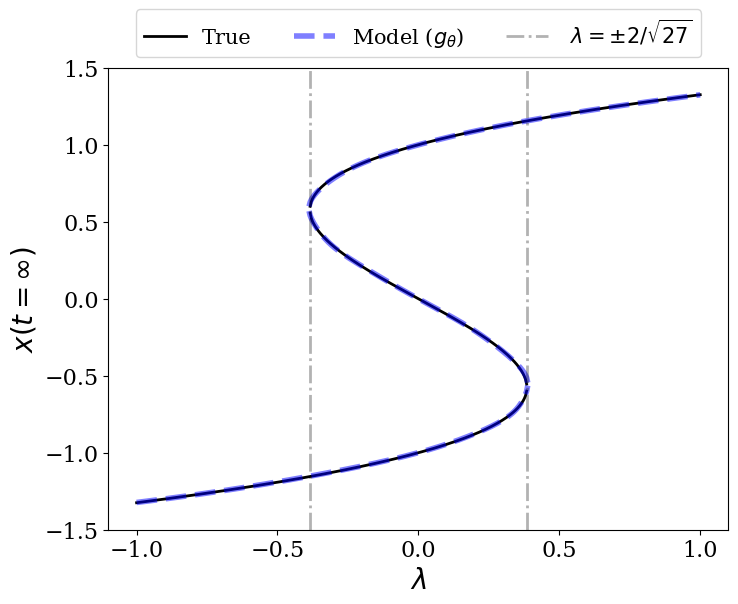

In [12]:
plt.figure(figsize=(8,6),)

x_star, idx = process_solutions(true_roots)
for k, (xi, idx_i) in enumerate(zip(x_star, idx)):
    plt.plot(lam_lin[idx_i], xi,
             c='black',lw=2, zorder=1,
             label="True" if k == 0 else None)

x_star, idx = process_solutions(model_roots)
for k, (xi, idx_i) in enumerate(zip(x_star, idx)):
    xi = scaler.inverse_transform(np.array(xi).reshape(-1,1))
    plt.plot(lam_lin[idx_i], xi,
             c='blue', linestyle='--', alpha=0.5, lw=4, zorder=2,
             label=r"Model ($g_\theta$)" if k == 0 else None)

plt.axvline(-2/np.sqrt(27), c='black', linestyle="-.", alpha=0.3, lw=2)
plt.axvline(2/np.sqrt(27), c='black', linestyle="-.", alpha=0.3, lw=2,
            label=r" $\lambda = \pm 2/\sqrt{27}$")

plt.xlabel(r"$\lambda$", fontsize=20)
plt.ylabel(r"$x(t = \infty)$",fontsize=20)

# plt.tick_params(axis='both', which='major', labelsize=20)
plt.yticks([ -1.5,-1,-0.5, 0, 0.5,1,1.5], fontsize=16)
plt.xticks([ -1,-0.5, 0, 0.5,1], fontsize=16)


plt.legend(fontsize=15,loc='lower center', ncol = 3, bbox_to_anchor = (0.5,1))
plt.savefig("hysteresis-bifurcation.png")
plt.show()
